In [20]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset

import torchvision
from torchvision import datasets, transforms, models

from sklearn.metrics import classification_report, confusion_matrix
import random
import warnings
warnings.filterwarnings("ignore")

# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Libraries loaded successfully!")
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")
print(f"Torchvision version: {torchvision.__version__}")

✅ Libraries loaded successfully!
🖥️  Using device: cpu
🔥 PyTorch version: 2.10.0+cpu
🖼️  Torchvision version: 0.25.0+cpu


In [24]:
# CELL 2 — FIXED paths

import os

base_path  = "/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray"
train_path = os.path.join(base_path, "train")
test_path  = os.path.join(base_path, "test")
val_path   = os.path.join(base_path, "val")

print("Base path contents:")
print(os.listdir(base_path))

print("\nTrain folder contents:")
train_folders = os.listdir(train_path)
print(train_folders)

print("\nTest folder contents:")
test_folders = os.listdir(test_path)
print(test_folders)

# Count images in each class
for split_name, split_path in [("TRAIN", train_path), ("TEST", test_path)]:
    print(f"\n{split_name} class breakdown:")
    for cls in os.listdir(split_path):
        cls_path = os.path.join(split_path, cls)
        if os.path.isdir(cls_path):
            count = len(os.listdir(cls_path))
            print(f"   {cls}: {count} images")

print("\nDataset paths verified successfully!")

📁 Base path contents:
['chest_xray', '__MACOSX', 'val', 'test', 'train']

📂 Train folder contents:
['PNEUMONIA', 'NORMAL']

📂 Test folder contents:
['PNEUMONIA', 'NORMAL']

📊 TRAIN class breakdown:
   PNEUMONIA: 3875 images
   NORMAL: 1341 images

📊 TEST class breakdown:
   PNEUMONIA: 390 images
   NORMAL: 234 images

✅ Dataset paths verified successfully!


In [25]:
# CELL 3 — Define image transformations

# ImageNet mean and std (used because ResNet was pretrained on ImageNet)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# Training transforms: include augmentation to improve generalization
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),           # ResNet expects 224x224
    transforms.Grayscale(num_output_channels=3),  # Convert grayscale X-rays to 3-channel
    transforms.RandomHorizontalFlip(),       # Random horizontal flip for augmentation
    transforms.RandomRotation(10),           # Slight random rotation
    transforms.ColorJitter(brightness=0.2),  # Adjust brightness slightly
    transforms.ToTensor(),                   # Convert PIL image to PyTorch tensor
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)  # Normalize
])

# Test/Val transforms: no augmentation, just resize + normalize
test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

print("Transforms defined!")
print(f"\nTraining transforms:\n{train_transforms}")
print(f"\nTest transforms:\n{test_transforms}")

✅ Transforms defined!

🔄 Training transforms:
Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    Grayscale(num_output_channels=3)
    RandomHorizontalFlip(p=0.5)
    RandomRotation(degrees=[-10.0, 10.0], interpolation=nearest, expand=False, fill=0)
    ColorJitter(brightness=(0.8, 1.2), contrast=None, saturation=None, hue=None)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

🔄 Test transforms:
Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    Grayscale(num_output_channels=3)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


In [26]:
# CELL 4 — Load datasets using ImageFolder

# ImageFolder automatically assigns class labels based on subfolder names
# (NORMAL → 0, PNEUMONIA → 1 — alphabetical order)

full_train_dataset = datasets.ImageFolder(root=train_path, transform=train_transforms)
full_test_dataset  = datasets.ImageFolder(root=test_path,  transform=test_transforms)

# Display class mapping
print(f"Class-to-index mapping: {full_train_dataset.class_to_idx}")
print(f"\nFull training dataset size : {len(full_train_dataset)} images")
print(f"Full test dataset size     : {len(full_test_dataset)} images")

# Count per class in training set
train_labels = [label for _, label in full_train_dataset.samples]
class_names  = full_train_dataset.classes
for i, cls in enumerate(class_names):
    count = train_labels.count(i)
    print(f"   Train → {cls}: {count}")

print("\nDatasets loaded successfully!")

📚 Class-to-index mapping: {'NORMAL': 0, 'PNEUMONIA': 1}

📦 Full training dataset size : 5216 images
📦 Full test dataset size     : 624 images
   Train → NORMAL: 1341
   Train → PNEUMONIA: 3875

✅ Datasets loaded successfully!


In [27]:
# CELL 5 — Create a subset for faster training (20-30% of data)

def create_balanced_subset(dataset, fraction=0.25, seed=42):
    """
    Creates a balanced subset of a dataset.
    Ensures roughly equal representation of each class.
    
    Args:
        dataset  : Full ImageFolder dataset
        fraction : Fraction of data to keep (0.25 = 25%)
        seed     : Random seed for reproducibility
    
    Returns:
        Subset of the dataset
    """
    random.seed(seed)
    
    # Group indices by class
    class_indices = {}
    for idx, (_, label) in enumerate(dataset.samples):
        class_indices.setdefault(label, []).append(idx)
    
    selected_indices = []
    for label, indices in class_indices.items():
        random.shuffle(indices)
        n_select = max(1, int(len(indices) * fraction))
        selected_indices.extend(indices[:n_select])
    
    random.shuffle(selected_indices)
    return Subset(dataset, selected_indices)

# Apply subset — using 25% of training data and 30% of test data
train_subset = create_balanced_subset(full_train_dataset, fraction=0.25)
test_subset  = create_balanced_subset(full_test_dataset,  fraction=0.30)

print(f"Subset created!")
print(f"Training subset size : {len(train_subset)} images  (from {len(full_train_dataset)})")
print(f"Test subset size     : {len(test_subset)} images  (from {len(full_test_dataset)})")
print(f"\n Using ~25% of train data for fast training (~30-45 min on GPU)")

✅ Subset created!
📦 Training subset size : 1303 images  (from 5216)
📦 Test subset size     : 187 images  (from 624)

💡 Using ~25% of train data for fast training (~30-45 min on GPU)


In [28]:
# CELL 6 — Create DataLoaders

# DataLoaders handle batching, shuffling, and parallel data loading
train_loader = DataLoader(
    train_subset,
    batch_size=32,       # Process 32 images at a time
    shuffle=True,        # Shuffle training data each epoch
    num_workers=2,       # Parallel workers for data loading
    pin_memory=True      # Speeds up GPU transfer
)

test_loader = DataLoader(
    test_subset,
    batch_size=32,
    shuffle=False,       # No need to shuffle test data
    num_workers=2,
    pin_memory=True
)

# Quick sanity check — peek at a single batch
sample_images, sample_labels = next(iter(train_loader))
print(f"DataLoaders created!")
print(f"\n Batch info:")
print(f"   Image tensor shape : {sample_images.shape}  → [batch, channels, H, W]")
print(f"   Labels tensor shape: {sample_labels.shape}  → [batch]")
print(f"   Label values (0=NORMAL, 1=PNEUMONIA): {sample_labels[:8].tolist()}")
print(f"\n Training batches : {len(train_loader)}")
print(f"Test batches     : {len(test_loader)}")

✅ DataLoaders created!

🔢 Batch info:
   Image tensor shape : torch.Size([32, 3, 224, 224])  → [batch, channels, H, W]
   Labels tensor shape: torch.Size([32])  → [batch]
   Label values (0=NORMAL, 1=PNEUMONIA): [0, 1, 0, 1, 1, 1, 1, 1]

📊 Training batches : 41
📊 Test batches     : 6


In [29]:
# CELL 7 — Initialize ResNet18 model with Transfer Learning

# Load ResNet18 pretrained on ImageNet
model = models.resnet18(pretrained=True)

# --- Step 1: Freeze ALL layers ---
# We don't want to retrain the feature extractor (too slow, too much data needed)
for param in model.parameters():
    param.requires_grad = False

# --- Step 2: Replace the final fully connected layer ---
# Original ResNet18 fc: Linear(512, 1000)  → 1000 ImageNet classes
# We replace it with:   Linear(512, 2)     → 2 classes (NORMAL, PNEUMONIA)
num_features = model.fc.in_features  # = 512
model.fc = nn.Linear(num_features, 2)
# Only this new fc layer has requires_grad=True by default

# Move model to GPU if available
model = model.to(device)

# Summary
total_params    = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("ResNet18 model initialized!")
print(f"\n Model Architecture (final layer):")
print(f"   {model.fc}")
print(f"\n Parameter counts:")
print(f"   Total parameters    : {total_params:,}")
print(f"   Trainable parameters: {trainable_params:,}  (only the final layer)")
print(f"   Frozen parameters   : {total_params - trainable_params:,}")
print(f"\n Model is on: {next(model.parameters()).device}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 311MB/s]


✅ ResNet18 model initialized!

🧠 Model Architecture (final layer):
   Linear(in_features=512, out_features=2, bias=True)

📊 Parameter counts:
   Total parameters    : 11,177,538
   Trainable parameters: 1,026  (only the final layer)
   Frozen parameters   : 11,176,512

🖥️  Model is on: cpu


In [30]:
# CELL 8 — Define loss function and optimizer

# CrossEntropyLoss is standard for multi-class classification
# It combines LogSoftmax + NLLLoss internally
criterion = nn.CrossEntropyLoss()

# Adam optimizer — only optimize the final FC layer (trainable params)
# lr=0.001 is a safe default for fine-tuning
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.001
)

# Learning rate scheduler — reduces LR by 50% every 2 epochs
# Helps fine-tune more precisely in later epochs
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=2, gamma=0.5)

print(" Loss function and optimizer defined!")
print(f"\n Loss function : CrossEntropyLoss")
print(f" Optimizer     : Adam (lr=0.001)")
print(f" LR Scheduler  : StepLR (step=2, gamma=0.5 → halves LR every 2 epochs)")
print(f"\n Only the final FC layer weights will be updated during training.")

✅ Loss function and optimizer defined!

📉 Loss function : CrossEntropyLoss
⚙️  Optimizer     : Adam (lr=0.001)
📅 LR Scheduler  : StepLR (step=2, gamma=0.5 → halves LR every 2 epochs)

💡 Only the final FC layer weights will be updated during training.


In [31]:
# CELL 9 — Training loop (3 epochs)

NUM_EPOCHS = 3
train_losses     = []
train_accuracies = []

print(" Starting training...\n")
print("=" * 60)

for epoch in range(NUM_EPOCHS):
    model.train()  # Set model to training mode
    
    running_loss    = 0.0
    correct         = 0
    total           = 0
    
    for batch_idx, (images, labels) in enumerate(train_loader):
        # Move data to GPU/CPU
        images = images.to(device)
        labels = labels.to(device)
        
        # --- Forward pass ---
        optimizer.zero_grad()        # Clear previous gradients
        outputs = model(images)      # Get predictions (logits)
        loss    = criterion(outputs, labels)  # Compute loss
        
        # --- Backward pass ---
        loss.backward()              # Compute gradients
        optimizer.step()             # Update weights
        
        # Track metrics
        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)  # Get class with highest score
        correct      += (predicted == labels).sum().item()
        total        += labels.size(0)
        
        # Print progress every 10 batches
        if (batch_idx + 1) % 10 == 0:
            batch_acc = 100.0 * correct / total
            print(f"  Epoch [{epoch+1}/{NUM_EPOCHS}] | "
                  f"Batch [{batch_idx+1}/{len(train_loader)}] | "
                  f"Loss: {loss.item():.4f} | "
                  f"Acc: {batch_acc:.2f}%")
    
    # Compute epoch-level metrics
    epoch_loss = running_loss / total
    epoch_acc  = 100.0 * correct / total
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)
    
    # Step the LR scheduler
    scheduler.step()
    current_lr = scheduler.get_last_lr()[0]
    
    print(f"\n{'='*60}")
    print(f"   Epoch {epoch+1} Complete | "
          f"Avg Loss: {epoch_loss:.4f} | "
          f"Train Accuracy: {epoch_acc:.2f}% | "
          f"LR: {current_lr:.6f}")
    print(f"{'='*60}\n")

print("Training complete!")

🚀 Starting training...

  Epoch [1/3] | Batch [10/41] | Loss: 0.7010 | Acc: 67.19%
  Epoch [1/3] | Batch [20/41] | Loss: 0.4555 | Acc: 71.56%
  Epoch [1/3] | Batch [30/41] | Loss: 0.6721 | Acc: 72.19%
  Epoch [1/3] | Batch [40/41] | Loss: 0.2909 | Acc: 75.78%

  ✅ Epoch 1 Complete | Avg Loss: 0.5328 | Train Accuracy: 76.06% | LR: 0.001000

  Epoch [2/3] | Batch [10/41] | Loss: 0.3115 | Acc: 82.19%
  Epoch [2/3] | Batch [20/41] | Loss: 0.2977 | Acc: 85.47%
  Epoch [2/3] | Batch [30/41] | Loss: 0.2315 | Acc: 87.50%
  Epoch [2/3] | Batch [40/41] | Loss: 0.3556 | Acc: 87.11%

  ✅ Epoch 2 Complete | Avg Loss: 0.3115 | Train Accuracy: 87.18% | LR: 0.000500

  Epoch [3/3] | Batch [10/41] | Loss: 0.2375 | Acc: 90.00%
  Epoch [3/3] | Batch [20/41] | Loss: 0.1854 | Acc: 90.62%
  Epoch [3/3] | Batch [30/41] | Loss: 0.2435 | Acc: 89.69%
  Epoch [3/3] | Batch [40/41] | Loss: 0.1769 | Acc: 90.08%

  ✅ Epoch 3 Complete | Avg Loss: 0.2548 | Train Accuracy: 90.18% | LR: 0.000500

🎉 Training complete!


In [32]:
# CELL 10 — Evaluate on test set

model.eval()  # Set model to evaluation mode (disables dropout, batchnorm behaves differently)

all_preds  = []
all_labels = []
correct    = 0
total      = 0

print(" Evaluating on test set...\n")

with torch.no_grad():  # Disable gradient computation for speed
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        
        outputs   = model(images)
        _, predicted = torch.max(outputs, 1)
        
        correct     += (predicted == labels).sum().item()
        total       += labels.size(0)
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Final accuracy
final_accuracy = 100.0 * correct / total
class_names    = full_train_dataset.classes  # ['NORMAL', 'PNEUMONIA']

print(f"{'='*50}")
print(f" Final Test Accuracy: {final_accuracy:.2f}%")
print(f"  Correct: {correct} / {total}")
print(f"{'='*50}\n")

# Detailed classification report
print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
print(f"Confusion Matrix:")
print(f"            Predicted NORMAL  Predicted PNEUMONIA")
print(f"  Actual NORMAL     {cm[0][0]:<12}  {cm[0][1]}")
print(f"  Actual PNEUMONIA  {cm[1][0]:<12}  {cm[1][1]}")

🔍 Evaluating on test set...

  🎯 Final Test Accuracy: 87.70%
  ✅ Correct: 164 / 187

📊 Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.91      0.74      0.82        70
   PNEUMONIA       0.86      0.96      0.91       117

    accuracy                           0.88       187
   macro avg       0.89      0.85      0.86       187
weighted avg       0.88      0.88      0.87       187

📊 Confusion Matrix:
            Predicted NORMAL  Predicted PNEUMONIA
  Actual NORMAL     52            18
  Actual PNEUMONIA  5             112


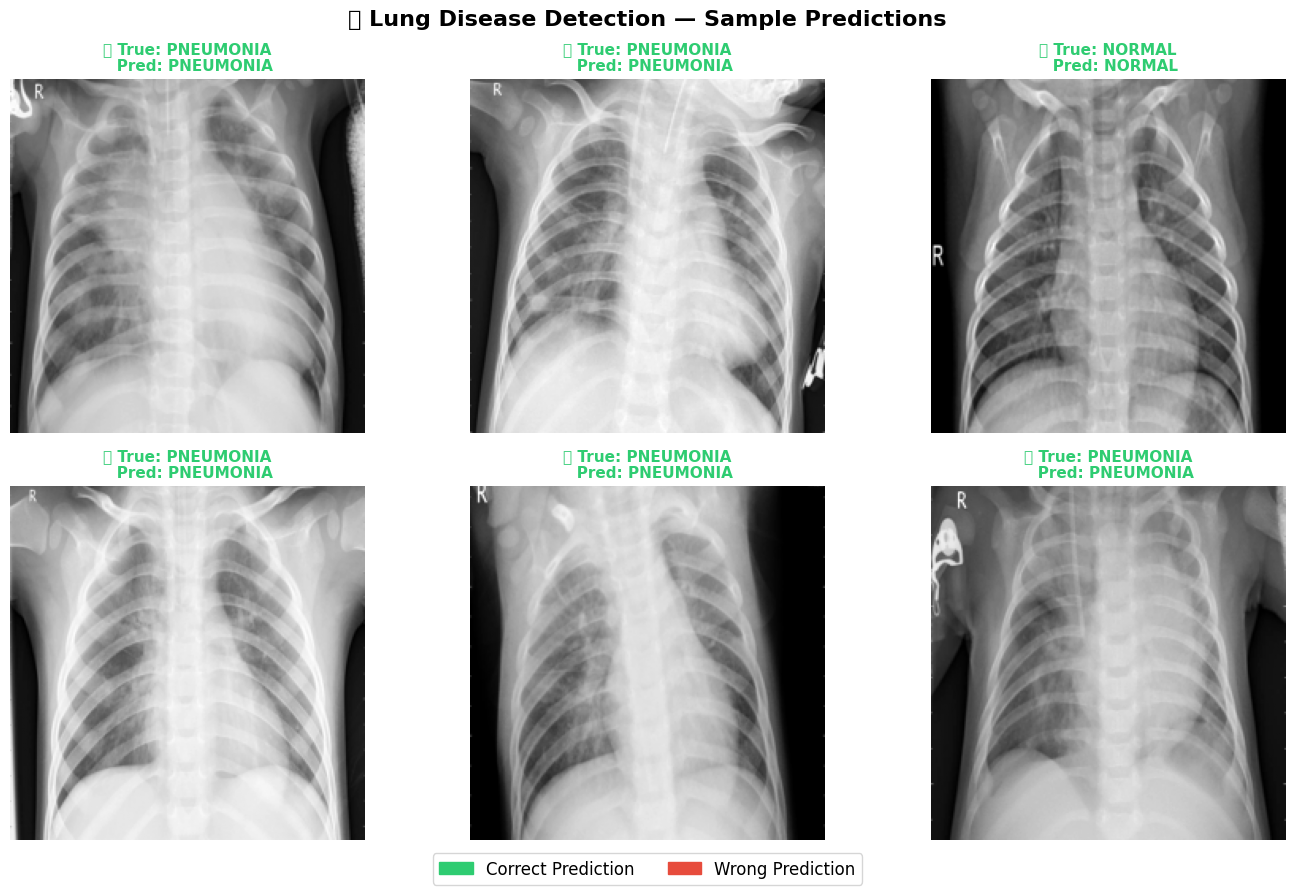

✅ Visualization complete! Saved as sample_predictions.png


In [33]:
# CELL 11 — Visualize 6 sample predictions

def denormalize(tensor):
    """Reverses ImageNet normalization for display."""
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return torch.clamp(tensor * std + mean, 0, 1)

model.eval()
class_names = full_train_dataset.classes  # ['NORMAL', 'PNEUMONIA']

# Grab one batch from the test loader
sample_images, sample_labels = next(iter(test_loader))
sample_images_gpu = sample_images.to(device)

with torch.no_grad():
    outputs = model(sample_images_gpu)
    _, preds = torch.max(outputs, 1)

preds = preds.cpu()

# Plot 6 predictions
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
fig.suptitle("Lung Disease Detection — Sample Predictions", fontsize=16, fontweight='bold')

for i, ax in enumerate(axes.flat):
    img = denormalize(sample_images[i])
    img_np = img.permute(1, 2, 0).numpy()  # C x H x W → H x W x C
    
    true_label = class_names[sample_labels[i].item()]
    pred_label = class_names[preds[i].item()]
    is_correct = (true_label == pred_label)
    
    # Use grayscale for X-ray look
    ax.imshow(img_np[:, :, 0], cmap='gray')
    
    # Color border: green = correct, red = wrong
    border_color = '#2ecc71' if is_correct else '#e74c3c'
    for spine in ax.spines.values():
        spine.set_edgecolor(border_color)
        spine.set_linewidth(4)
    
    # Title with prediction info
    status = "1" if is_correct else "0"
    ax.set_title(
        f"{status} True: {true_label}\n   Pred: {pred_label}",
        fontsize=11,
        color=border_color,
        fontweight='bold'
    )
    ax.axis('off')

# Legend
correct_patch = mpatches.Patch(color='#2ecc71', label='Correct Prediction')
wrong_patch   = mpatches.Patch(color='#e74c3c', label='Wrong Prediction')
fig.legend(handles=[correct_patch, wrong_patch], loc='lower center',
           ncol=2, fontsize=12, frameon=True)

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig("sample_predictions.png", dpi=150, bbox_inches='tight')
plt.show()
print(" Visualization complete! Saved as sample_predictions.png")

🔬 Running simulated nodule detection on sample X-rays...

  📸 person1676_virus_2892.jpeg → 40 candidate nodule(s) detected
  📸 person1650_virus_2852.jpeg → 28 candidate nodule(s) detected
  📸 person22_virus_55.jpeg → 22 candidate nodule(s) detected


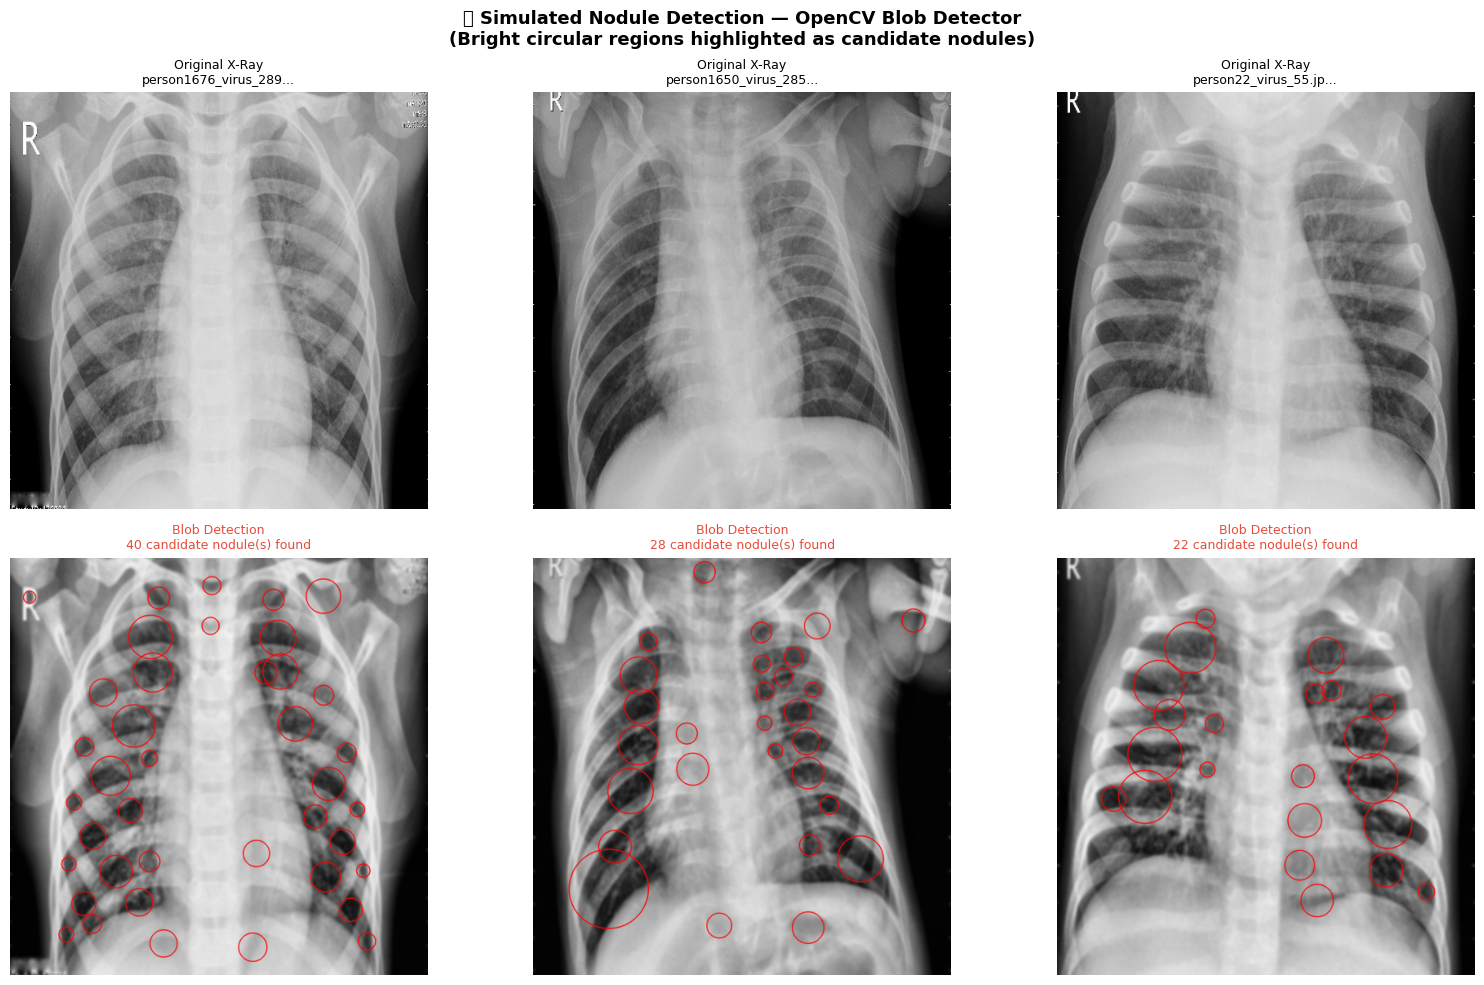


✅ Nodule detection complete!
💡 Note: This is a simplified demonstration using blob detection.
   Clinical nodule detection requires far more sophisticated methods.


In [34]:
# CELL 12 (BONUS) — Simulated Nodule Detection using OpenCV Blob Detection

import cv2

print("Running simulated nodule detection on sample X-rays...\n")

# Grab a few raw images directly from disk for OpenCV processing
sample_dir = os.path.join(test_path, "PNEUMONIA")
sample_files = [f for f in os.listdir(sample_dir) if f.endswith(('.jpeg', '.jpg', '.png'))][:3]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Simulated Nodule Detection — OpenCV Blob Detector\n"
             "(Bright circular regions highlighted as candidate nodules)",
             fontsize=13, fontweight='bold')

# Configure SimpleBlobDetector parameters
params = cv2.SimpleBlobDetector_Params()
params.filterByArea      = True
params.minArea           = 150      # Minimum blob size (pixels²)
params.maxArea           = 5000     # Maximum blob size
params.filterByCircularity = True
params.minCircularity    = 0.3      # How circular the blob must be (1.0 = perfect circle)
params.filterByConvexity = False
params.filterByInertia   = False

detector = cv2.SimpleBlobDetector_create(params)

for i, fname in enumerate(sample_files):
    img_path = os.path.join(sample_dir, fname)
    
    # --- Load and preprocess ---
    img_bgr  = cv2.imread(img_path)
    img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    img_gray = cv2.resize(img_gray, (512, 512))
    
    # Enhance contrast using CLAHE (Contrast Limited Adaptive Histogram Equalization)
    clahe      = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    img_clahe  = clahe.apply(img_gray)
    
    # Apply Gaussian blur to reduce noise before blob detection
    img_blurred = cv2.GaussianBlur(img_clahe, (7, 7), 0)
    
    # Detect blobs (potential nodules)
    keypoints  = detector.detect(img_blurred)
    
    # Draw detected blobs on a copy of the image
    img_with_kp = cv2.drawKeypoints(
        img_blurred,
        keypoints,
        np.array([]),
        (255, 0, 0),
        cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
    )
    
    # --- Plot original vs detected ---
    axes[0][i].imshow(img_gray, cmap='gray')
    axes[0][i].set_title(f"Original X-Ray\n{fname[:20]}...", fontsize=9)
    axes[0][i].axis('off')
    
    axes[1][i].imshow(img_with_kp, cmap='gray')
    axes[1][i].set_title(
        f"Blob Detection\n{len(keypoints)} candidate nodule(s) found",
        fontsize=9,
        color='#e74c3c' if len(keypoints) > 0 else '#2ecc71'
    )
    axes[1][i].axis('off')
    
    print(f"  {fname[:30]} → {len(keypoints)} candidate nodule(s) detected")

plt.tight_layout()
plt.savefig("nodule_detection.png", dpi=150, bbox_inches='tight')
plt.show()

print("\n Nodule detection complete!")
print(" Note: This is a simplified demonstration using blob detection.")
print("   Clinical nodule detection requires far more sophisticated methods.")